In [1]:
import pandas as pd
df_raw = pd.read_csv("whatsapp_chat.csv")
df_raw_cleaned = pd.read_csv("whatsapp_chat_cleaned.csv")
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.max_columns", 15)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 20)
print(df_raw.head())
print(df_raw_cleaned.head())


   message_id                                  source_file             chat_name        date   time             datetime day_of_week                sender  \
0           1  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  13:07  2023-02-21T13:07:00     Tuesday                SYSTEM   
1           2  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  21:47  2023-02-21T21:47:00     Tuesday  Awais Ibrahim BU PGC   
2           3  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  21:47  2023-02-21T21:47:00     Tuesday  Awais Ibrahim BU PGC   
3           4  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  21:50  2023-02-21T21:50:00     Tuesday  Awais Ibrahim BU PGC   
4           5  WhatsApp Chat with Awais Ibrahim BU PGC.txt  Awais Ibrahim BU PGC  2023-02-21  21:50  2023-02-21T21:50:00     Tuesday  Awais Ibrahim BU PGC   

                                             messag

In [2]:
sender_counts = df_raw_cleaned["sender"].value_counts()
print(f"Total unique senders: {len(sender_counts)}")
print("\nTop 20 senders by message count:")
print(sender_counts.head(20))

senders_top8 = sender_counts.head(8).index.tolist()
print(f"\nTop 8 senders: {senders_top8}")
df_8 = df_raw_cleaned[df_raw_cleaned["sender"].isin(senders_top8)].copy()
print(f"Messages from top 8: {len(df_8)}")


Total unique senders: 36

Top 20 senders by message count:
sender
Hamza Ihsan                32399
Mubarak Andrabi BU         13447
Awais Ibrahim BU PGC        7635
Nofal Zia (BU)              6318
Mazen مازین (BU)            2936
Chomu Hashim Nazir (BU)     2843
Humayun Tariq BU            2611
Rafay Ali (BU)              2049
Fuzail BU                   1809
Hashir BU                   1480
Wajahat BU                  1425
Momin BU                    1418
Laiba BU                    1391
Muzammil BU                 1345
Fasih (BU)                  1196
Azlan Shah (BU) CR          1157
Zulfiqar Ali BU             1083
Sidra BU                     858
Usama (BU)                   673
Saad Front Seater BU         570
Name: count, dtype: int64

Top 8 senders: ['Hamza Ihsan', 'Mubarak Andrabi BU', 'Awais Ibrahim BU PGC', 'Nofal Zia (BU)', 'Mazen مازین (BU)', 'Chomu Hashim Nazir (BU)', 'Humayun Tariq BU', 'Rafay Ali (BU)']
Messages from top 8: 70238


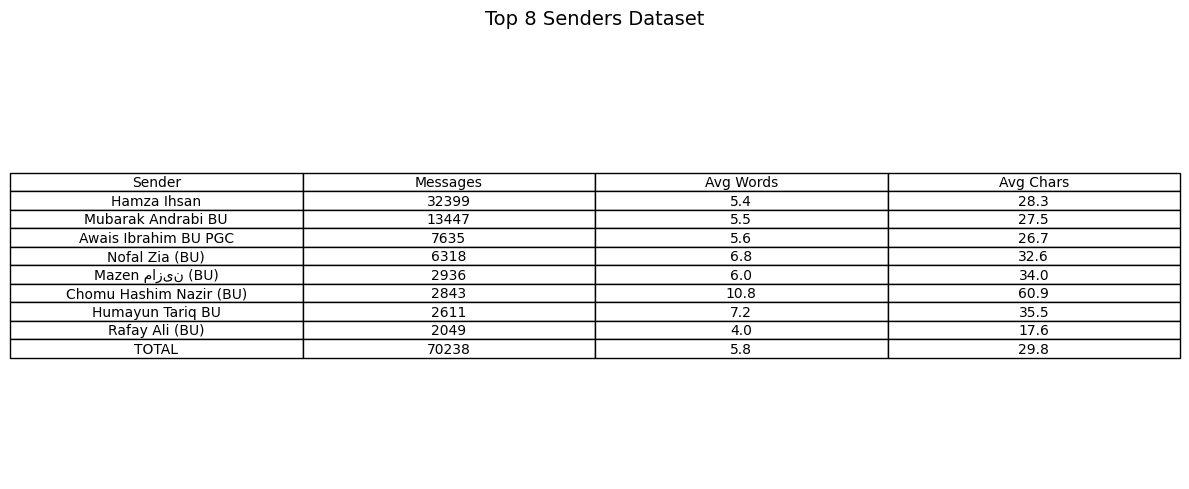

In [3]:
import matplotlib.pyplot as plt
counts = df_8["sender"].value_counts()
fig, ax = plt.subplots(figsize=(12, len(counts) * 0.5 + 1))
ax.axis("tight"); ax.axis("off")
table_data = []; t_msgs=0; t_chars=0; t_words=0
for s in counts.index:
    sd = df_8[df_8["sender"] == s]
    n = len(sd); aw = round(sd["word_count"].mean(), 1); ac = round(sd["char_count"].mean(), 1)
    t_msgs+=n; t_words+=sd["word_count"].sum(); t_chars+=sd["char_count"].sum()
    table_data.append([s, n, aw, ac])
table_data.append(["TOTAL", t_msgs, round(t_words/t_msgs,1), round(t_chars/t_msgs,1)])
ax.table(cellText=table_data, colLabels=["Sender","Messages","Avg Words","Avg Chars"], cellLoc="center", loc="center")
plt.title("Top 8 Senders Dataset", fontsize=14, pad=20)
plt.tight_layout(); plt.show()


In [4]:
import numpy as np
df_filtered = df_8[(df_8["word_count"] > 2) & (df_8["word_count"] <= 100)].copy()
print(f"After word_count filter: {len(df_filtered)} messages")

TARGET_SIZE = 3000; target_mean = 10; target_std = 6
np.random.seed(42)
target_wc = np.clip(np.round(np.random.normal(target_mean, target_std, TARGET_SIZE)).astype(int), 1, None)

balanced_dfs = []
for sender in df_filtered["sender"].unique():
    sd = df_filtered[df_filtered["sender"] == sender].copy()
    if len(sd) >= TARGET_SIZE:
        sampled_list = []; sd = sd.reset_index(drop=True)
        for tw in target_wc:
            sd["diff"] = abs(sd["word_count"] - tw)
            ci = sd["diff"].idxmin()
            sampled_list.append(sd.loc[ci]); sd = sd.drop(ci)
        balanced_dfs.append(pd.DataFrame(sampled_list))
    else:
        balanced_dfs.append(sd)

df_balanced = pd.concat(balanced_dfs, ignore_index=True)
print(f"Resulting distribution:")
print(df_balanced["word_count"].describe())
print(f"\nMessages per sender:")
print(df_balanced["sender"].value_counts())


After word_count filter: 45939 messages


Resulting distribution:
count    19350.000000
mean         8.394987
std          5.600902
min          3.000000
25%          5.000000
50%          7.000000
75%         11.000000
max         95.000000
Name: word_count, dtype: float64

Messages per sender:
sender
Nofal Zia (BU)             3000
Mubarak Andrabi BU         3000
Hamza Ihsan                3000
Awais Ibrahim BU PGC       3000
Chomu Hashim Nazir (BU)    2295
Humayun Tariq BU           1981
Mazen مازین (BU)           1789
Rafay Ali (BU)             1285
Name: count, dtype: int64


In [5]:
print("Columns:", df_balanced.columns.tolist())
print(f"Total: {len(df_balanced)}")


Columns: ['message_id', 'sender', 'word_count', 'char_count', 'message_clean', 'message_clean_lower', 'split', 'diff']
Total: 19350


In [6]:
from sklearn.model_selection import train_test_split
df_balanced["custom_split"] = "train"
for sender in df_balanced["sender"].unique():
    mask = df_balanced["sender"] == sender
    tr_idx, te_idx = train_test_split(df_balanced[mask].index, test_size=0.2, random_state=42)
    df_balanced.loc[te_idx, "custom_split"] = "test"

print("Split per sender:")
for s in df_balanced["sender"].unique():
    sd = df_balanced[df_balanced["sender"] == s]
    print(f"  {s[:30]}: {(sd.custom_split=='train').sum()} train, {(sd.custom_split=='test').sum()} test")
print(f"\nTotal: {len(df_balanced)} | Train: {(df_balanced.custom_split=='train').sum()} | Test: {(df_balanced.custom_split=='test').sum()}")


Split per sender:
  Nofal Zia (BU): 2400 train, 600 test
  Mubarak Andrabi BU: 2400 train, 600 test
  Hamza Ihsan: 2400 train, 600 test
  Awais Ibrahim BU PGC: 2400 train, 600 test
  Rafay Ali (BU): 1028 train, 257 test
  Chomu Hashim Nazir (BU): 1836 train, 459 test
  Humayun Tariq BU: 1584 train, 397 test
  Mazen مازین (BU): 1431 train, 358 test

Total: 19350 | Train: 15479 | Test: 3871


# Deductive Model: 8 Known Authors + UNKNOWN Class

Instead of a flat multi-class model (like test.ipynb), we add an **UNKNOWN** class
built from all other senders in the dataset. The model learns to distinguish each
known author from everyone else.

**Technique**: Char TF-IDF (3-5 grams) + Logistic Regression (best from test.ipynb)
**Classes**: 8 known + 1 UNKNOWN = 9 total


In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Split known data
train_data = df_balanced[df_balanced["custom_split"]=="train"].copy()
test_data = df_balanced[df_balanced["custom_split"]=="test"].copy()

known_senders = list(train_data["sender"].unique())
print(f"Known senders ({len(known_senders)}):")
for s in known_senders: print(f"  {s}")

# Build UNKNOWN from all other senders
other = df_raw_cleaned[~df_raw_cleaned["sender"].isin(known_senders)].copy()
other = other[(other["word_count"] > 2) & (other["word_count"] <= 100)]
print(f"\nOther senders available: {other['sender'].nunique()}, msgs: {len(other)}")

n_uk = min(len(train_data) // len(known_senders), len(other))
unk_train = other.sample(n=n_uk, random_state=42).copy()
unk_train["sender"] = "UNKNOWN"; unk_train["custom_split"] = "train"

other_test = df_raw_cleaned[~df_raw_cleaned["sender"].isin(known_senders)].copy()
other_test = other_test[(other_test["word_count"] > 2) & (other_test["word_count"] <= 100)]
n_uk_test = min(len(test_data) // len(known_senders), len(other_test))
unk_test = other_test.sample(n=n_uk_test, random_state=43).copy()
unk_test["sender"] = "UNKNOWN"; unk_test["custom_split"] = "test"
print(f"UNKNOWN: {n_uk} train, {n_uk_test} test")

# Combine
train_full = pd.concat([train_data, unk_train], ignore_index=True)
test_full = pd.concat([test_data, unk_test], ignore_index=True)
print(f"\nTrain: {len(train_full)}, Test: {len(test_full)}")

# Vectorize
vec = TfidfVectorizer(analyzer="char", ngram_range=(3, 5), max_features=10000, min_df=2)
X_tr = vec.fit_transform(train_full["message_clean_lower"])
X_te = vec.transform(test_full["message_clean_lower"])

# Train 9-class model
model = LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced", random_state=42)
model.fit(X_tr, train_full["sender"])
print("\nTraining complete!")


Known senders (8):
  Nofal Zia (BU)
  Mubarak Andrabi BU
  Hamza Ihsan
  Awais Ibrahim BU PGC
  Rafay Ali (BU)
  Chomu Hashim Nazir (BU)
  Humayun Tariq BU
  Mazen مازین (BU)

Other senders available: 28, msgs: 13569
UNKNOWN: 1934 train, 483 test

Train: 17413, Test: 4354



Training complete!


   DEDUCTIVE MODEL (8 Known + UNKNOWN) - FINAL RESULTS
Overall Accuracy: 0.6723 (67.23%)

Per-Class Metrics (sorted by F1):
                         precision    recall  f1-score  support
Chomu Hashim Nazir (BU)   0.796499  0.793028  0.794760    459.0
Mubarak Andrabi BU        0.729642  0.746667  0.738056    600.0
Nofal Zia (BU)            0.752727  0.690000  0.720000    600.0
Humayun Tariq BU          0.682809  0.710327  0.696296    397.0
Awais Ibrahim BU PGC      0.730627  0.660000  0.693520    600.0
Rafay Ali (BU)            0.595611  0.739300  0.659722    257.0
Hamza Ihsan               0.643836  0.626667  0.635135    600.0
Mazen مازین (BU)          0.506276  0.675978  0.578947    358.0
UNKNOWN                   0.541562  0.445135  0.488636    483.0


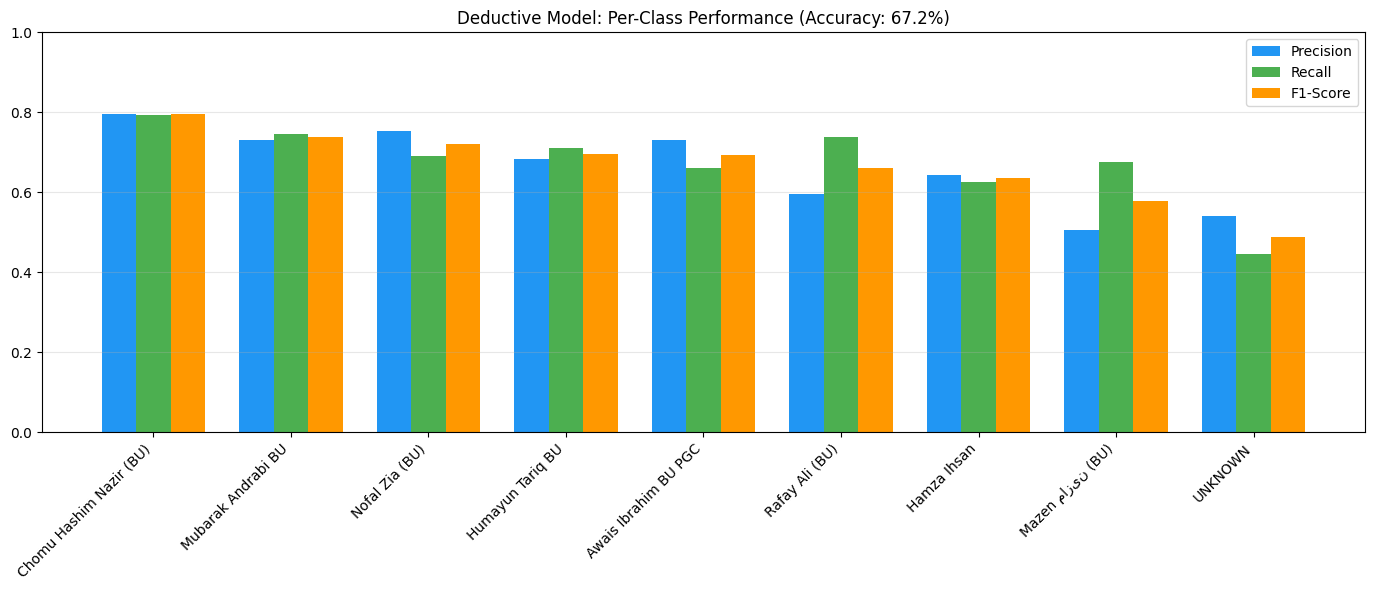

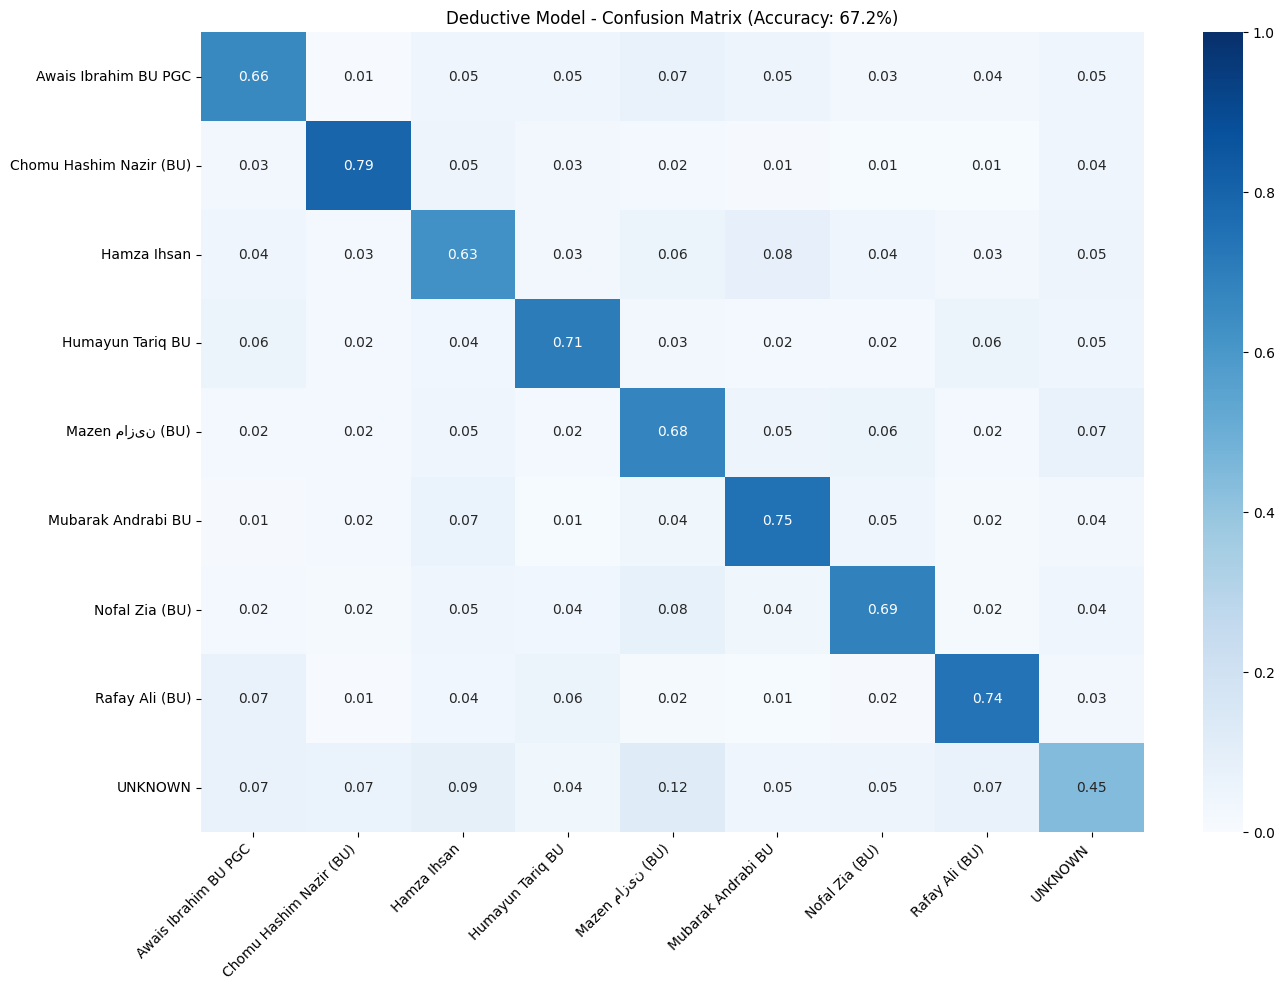

In [8]:
y_pred = model.predict(X_te)
y_true = test_full["sender"].values
accuracy = accuracy_score(y_true, y_pred)

report = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
sender_metrics = report_df.drop(["accuracy","macro avg","weighted avg"], errors="ignore")
sender_metrics_sorted = sender_metrics.sort_values("f1-score", ascending=False)

print("=" * 70)
print("   DEDUCTIVE MODEL (8 Known + UNKNOWN) - FINAL RESULTS")
print("=" * 70)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nPer-Class Metrics (sorted by F1):")
print(sender_metrics_sorted[["precision","recall","f1-score","support"]])

# ---- Plot 1: Per-class ----
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(sender_metrics_sorted)); w = 0.25
ax.bar(x-w, sender_metrics_sorted["precision"], w, label="Precision", color="#2196F3")
ax.bar(x, sender_metrics_sorted["recall"], w, label="Recall", color="#4CAF50")
ax.bar(x+w, sender_metrics_sorted["f1-score"], w, label="F1-Score", color="#FF9800")
ax.set_title(f"Deductive Model: Per-Class Performance (Accuracy: {accuracy*100:.1f}%)")
ax.set_xticks(x); ax.set_xticklabels([s[:25] for s in sender_metrics_sorted.index], rotation=45, ha="right")
ax.legend(); ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# ---- Plot 2: Confusion Matrix ----
labels = model.classes_
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_n = cm.astype("float") / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(cm_n, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[l[:25] for l in labels],
            yticklabels=[l[:25] for l in labels],
            ax=ax, vmin=0, vmax=1)
ax.set_title(f"Deductive Model - Confusion Matrix (Accuracy: {accuracy*100:.1f}%)")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()


In [9]:
# Compare: 8-known-only baseline vs 9-class (8 known + unknown)
X8_tr = vec.fit_transform(train_data["message_clean_lower"])
X8_te = vec.transform(test_data["message_clean_lower"])
m8 = LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced", random_state=42)
m8.fit(X8_tr, train_data["sender"])
p8 = m8.predict(X8_te)
a8 = accuracy_score(test_data["sender"], p8)

print("Model Comparison:")
print(f"  8-known baseline:  {a8*100:.2f}%")
print(f"  9-class (deductive): {accuracy*100:.2f}%")
print(f"  (lower due to harder task: distinguishing from UNKNOWN)")


Model Comparison:
  8-known baseline:  71.71%
  9-class (deductive): 67.23%
  (lower due to harder task: distinguishing from UNKNOWN)


In [10]:
import pickle, os
ded_model = {
    "type": "deductive_9class",
    "model": model,
    "vectorizer": vec,
    "accuracy": accuracy,
    "known_senders": known_senders,
    "author_list": list(model.classes_),
    "baseline_accuracy_8only": a8,
}
os.makedirs("models", exist_ok=True)
pkl_path = "models/ded_model_9class_top8.pkl"
with open(pkl_path, "wb") as f: pickle.dump(ded_model, f)

print(f"Saved to {pkl_path}")
print(f"Authors ({len(known_senders)}):")
for s in known_senders: print(f"  {s}")
print(f"\nAccuracy: {accuracy*100:.2f}%")
print(f"Baseline (8-only): {a8*100:.2f}%")


Saved to models/ded_model_9class_top8.pkl
Authors (8):
  Nofal Zia (BU)
  Mubarak Andrabi BU
  Hamza Ihsan
  Awais Ibrahim BU PGC
  Rafay Ali (BU)
  Chomu Hashim Nazir (BU)
  Humayun Tariq BU
  Mazen مازین (BU)

Accuracy: 67.23%
Baseline (8-only): 71.71%


In [11]:
tests = [
    "kal class mein nhi aaraha tha kya hua tha?",
    "bro ya bhi mera number hai save kar la",
    "assignment submit kar do kal tak",
    "yeh konsa subject hai?",
    "I would like to discuss the project timeline",
    "This is a random message from an unknown person",
]
for t in tests:
    X = vec.transform([t.lower()])
    proba = model.predict_proba(X)[0]
    pred = model.classes_[np.argmax(proba)]
    conf = max(proba)
    top3 = sorted(zip(model.classes_, proba), key=lambda x: -x[1])[:3]
    top3_str = ", ".join([f"{c}={p:.0%}" for c,p in top3])
    print(f"{t[:50]:50s} -> {pred:30s} ({conf:.1%})")
    print(f"  Top 3: {top3_str}")
    print()


kal class mein nhi aaraha tha kya hua tha?         -> UNKNOWN                        (22.7%)
  Top 3: UNKNOWN=23%, Mazen مازین (BU)=17%, Awais Ibrahim BU PGC=16%

bro ya bhi mera number hai save kar la             -> Hamza Ihsan                    (19.0%)
  Top 3: Hamza Ihsan=19%, Chomu Hashim Nazir (BU)=17%, Mubarak Andrabi BU=14%

assignment submit kar do kal tak                   -> Mazen مازین (BU)               (15.9%)
  Top 3: Mazen مازین (BU)=16%, Rafay Ali (BU)=12%, Mubarak Andrabi BU=12%

yeh konsa subject hai?                             -> UNKNOWN                        (29.3%)
  Top 3: UNKNOWN=29%, Chomu Hashim Nazir (BU)=23%, Nofal Zia (BU)=9%

I would like to discuss the project timeline       -> UNKNOWN                        (16.8%)
  Top 3: UNKNOWN=17%, Mazen مازین (BU)=14%, Awais Ibrahim BU PGC=13%

This is a random message from an unknown person    -> Mazen مازین (BU)               (19.4%)
  Top 3: Mazen مازین (BU)=19%, Humayun Tariq BU=13%, UNKNOWN=13%

